In [95]:
import pandas as pd
train=pd.read_csv('train.csv')
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [96]:
train['Store'].nunique()

45

#For IsHoliday columns


True → That week contains an important holiday (for example: Super Bowl, Labor Day, Thanksgiving, Christmas).

False → That week is a regular non-holiday week.

In [97]:
train.shape

(421570, 5)

In [98]:
train['Date'].min()

'2010-02-05'

In [99]:
train['Date'].max()

'2012-10-26'

In [100]:
train['IsHoliday'].value_counts()

IsHoliday
False    391909
True      29661
Name: count, dtype: int64

In [101]:
features = pd.read_csv('features.csv')
stores = pd.read_csv('stores.csv')

In [102]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [103]:
features['Date'].min()

'2010-02-05'

In [104]:
features['Date'].max()

'2013-07-26'

In [105]:
# pd.merge(left_df, right_df, on="column_name", how="type_of_join")



# Merge train with features
df = pd.merge(train, features, on=["Store", "Date", "IsHoliday"], how="left")

In [106]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [107]:
df['Date'].min()

'2010-02-05'

In [108]:
df['Date'].max()

'2012-10-26'

In [109]:
stores

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


In [110]:
stores['Store'].nunique()

45

In [111]:

# Merge with stores
df = pd.merge(df, stores, on="Store", how="left")

In [112]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [113]:

print("Final shape:", df.shape)
df.head()

Final shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


1. MarkDown1 – MarkDown5

MarkDown1 → MarkDown5 = Different types of promotional campaigns or discounts

Values are usually dollar amounts spent on promotions

NaN means:

No promotion that week

Or data not recorded

Why multiple markdown columns?

Retailers run different promotion categories, for example:

Seasonal discount

Clearance sale

Holiday promotion

Special event offer

Supplier-funded discount

Instead of one column, they store 5 separate promotion types.

Why important in ML?

Promotions directly affect Weekly_Sales:

More markdown → higher customer purchase → higher sales

2. Size

This represents the physical size of the store.

Meaning

Usually measured in square feet

Larger store → more products → more customers → higher sales potential

Example:

Size = 151,315 sq.ft → Large retail store

3. Unemployment

This is the regional unemployment rate where the store is located.

Meaning   1.Expressed as percentage

Example: 8.106 → about 8.1% unemployment

Why included?

Economic conditions affect shopping behavior:

High unemployment-----> 1.People spend less  2.Sales decrease

Low unemployment---->1.People spend more 2.Sales increase

In [114]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Fill MarkDown missing values with 0
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
df[markdown_cols] = df[markdown_cols].fillna(0)

# Verify
df.isna().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

In [115]:
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
weekly_sales

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30
...,...,...
138,2012-09-28,43734899.40
139,2012-10-05,47566639.31
140,2012-10-12,46128514.25
141,2012-10-19,45122410.57


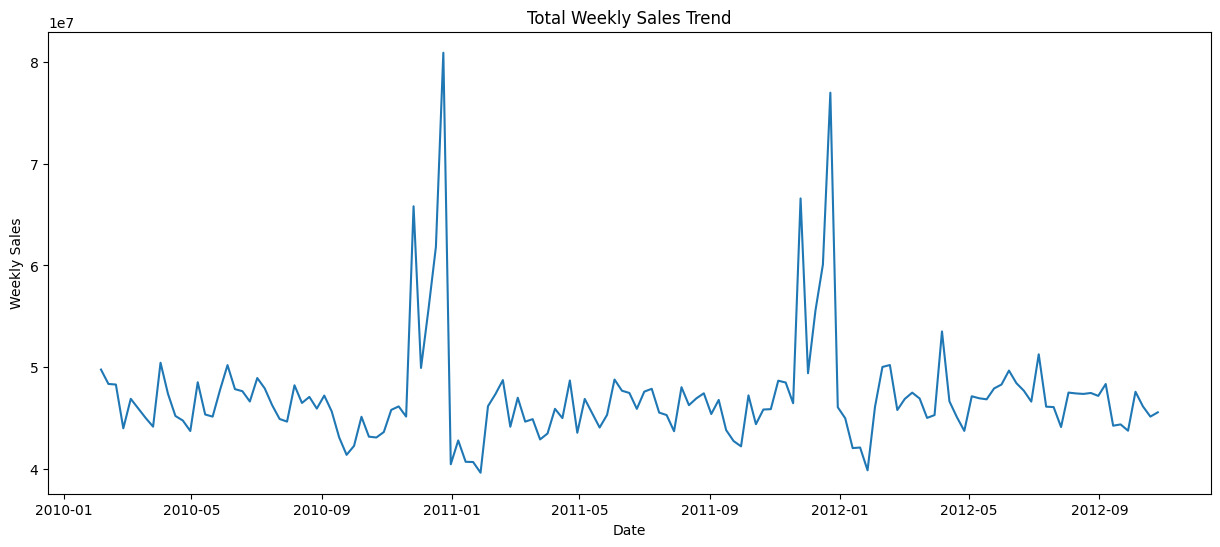

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(weekly_sales['Date'],weekly_sales['Weekly_Sales'])
plt.title("Total Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

In [117]:
weekly_sales['Year'] = weekly_sales['Date'].dt.year
weekly_sales['Week'] = weekly_sales['Date'].dt.isocalendar().week

weekly_sales

,Date,Weekly_Sales,Year,Week
0,2010-02-05,49750740.50,2010,5
1,2010-02-12,48336677.63,2010,6
2,2010-02-19,48276993.78,2010,7
3,2010-02-26,43968571.13,2010,8
4,2010-03-05,46871470.30,2010,9
...,...,...,...,...
138,2012-09-28,43734899.40,2012,39
139,2012-10-05,47566639.31,2012,40
140,2012-10-12,46128514.25,2012,41
141,2012-10-19,45122410.57,2012,42


In [118]:
# df.pivot(index="row_column", columns="column_to_expand", values="data_values")


pivot = weekly_sales.pivot(index='Week',columns='Year',values='Weekly_Sales')

pivot

Year,2010,2011,2012
Week,,,
1,NaN,42775787.77,44955421.95
2,NaN,40673678.04,42023078.48
3,NaN,40654648.03,42080996.56
4,NaN,39599852.99,39834974.67
5,49750740.50,46153111.12,46085608.09
6,48336677.63,47336192.79,50009407.92
7,48276993.78,48716164.12,50197056.96
8,43968571.13,44125859.84,45771506.57
9,46871470.30,46980603.74,46861034.97


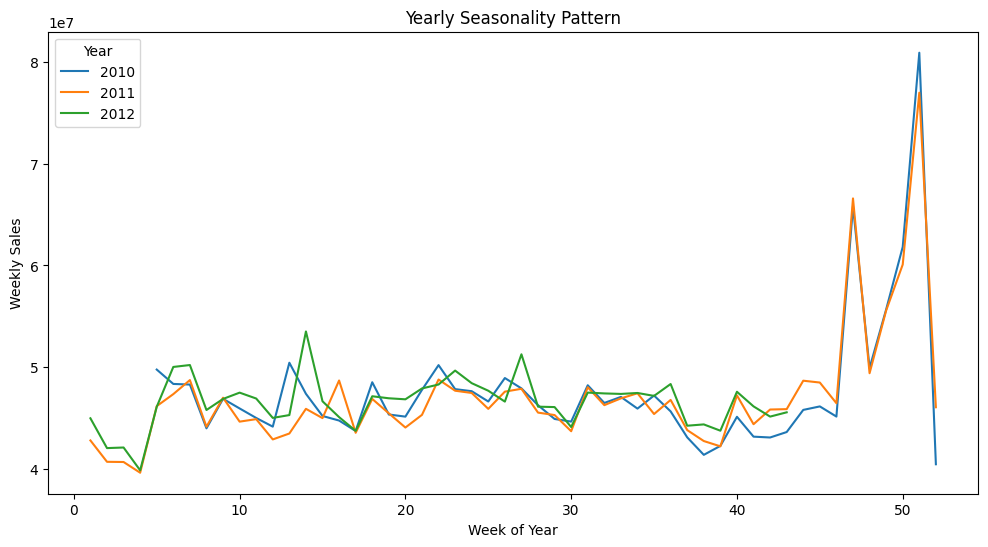

In [119]:
pivot.plot(figsize=(12,6))
plt.title("Yearly Seasonality Pattern")
plt.xlabel("Week of Year")
plt.ylabel("Weekly Sales")
plt.show()

In [120]:
# It is used to check whether a time-series is stationary or non-stationary.

from statsmodels.tsa.stattools import adfuller   #Augmented Dickey–Fuller test.

result = adfuller(weekly_sales["Weekly_Sales"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])


# p-value: 2.675979158986027e-07---->  This is much smaller than 0.05

ADF Statistic: -5.908297957186334
p-value: 2.675979158986027e-07


In the ADF test:

Null hypothesis (H₀) → Time series is non-stationary (has a unit root)

Alternative hypothesis (H₁) → Time series is stationary

We check the p-value:
p-value	Conclusion
< 0.05	Reject H₀ → Stationary ✅
≥ 0.05	Fail to reject H₀ → Non-stationary ❌

A time series is stationary when:

Mean is constant over time

Variance is constant

No trend or seasonality changing the distribution

Most forecasting models like:

ARIMA

SARIMA

Classical statistical models

require stationary data to work correctly.

In [121]:
# Train-test split (last 20% as test)
split_index = int(len(weekly_sales) * 0.8)

train = weekly_sales.iloc[:split_index]
test = weekly_sales.iloc[split_index:]

print(train.shape, test.shape)

(114, 4) (29, 4)


In [122]:
train.shape

(114, 4)

In [123]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train['Weekly_Sales'],order=(1,1,1),seasonal_order=(1,1,1,52))

sarima_result = model.fit()
print(sarima_result.summary())


                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                  114
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                -970.926
Date:                            Fri, 13 Feb 2026   AIC                           1951.853
Time:                                    15:52:50   BIC                           1962.407
Sample:                                         0   HQIC                          1955.989
                                            - 114                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1615      1.209      0.134      0.894      -2.208       2.531
ma.L1         -0.2769      1.188   

In [124]:
forecast = sarima_result.forecast(steps=len(test))
# test['Forecast'] = forecast.va

In [125]:
test["Forecast"] = forecast.values

In [126]:
test

,Date,Weekly_Sales,Year,Week,Forecast
114,2012-04-13,46629261.41,2012,15,5.192786e+07
115,2012-04-20,45072529.78,2012,16,5.488473e+07
116,2012-04-27,43716798.89,2012,17,5.052290e+07
117,2012-05-04,47124197.93,2012,18,5.351597e+07
118,2012-05-11,46925878.99,2012,19,5.219178e+07
119,2012-05-18,46823939.22,2012,20,5.101376e+07
120,2012-05-25,47892463.31,2012,21,5.217248e+07
121,2012-06-01,48281649.72,2012,22,5.518538e+07
122,2012-06-08,49651171.78,2012,23,5.415967e+07
123,2012-06-15,48412110.70,2012,24,5.396504e+07


In [127]:
train

,Date,Weekly_Sales,Year,Week
0,2010-02-05,49750740.50,2010,5
1,2010-02-12,48336677.63,2010,6
2,2010-02-19,48276993.78,2010,7
3,2010-02-26,43968571.13,2010,8
4,2010-03-05,46871470.30,2010,9
...,...,...,...,...
109,2012-03-09,47480454.11,2012,10
110,2012-03-16,46901504.94,2012,11
111,2012-03-23,44993794.45,2012,12
112,2012-03-30,45272862.02,2012,13


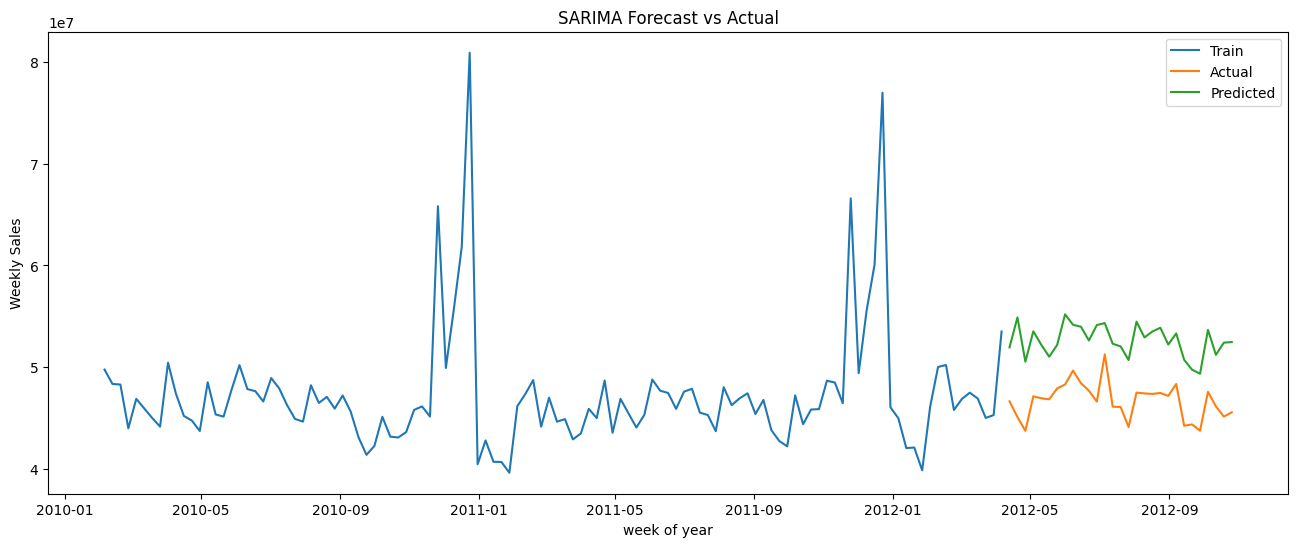

In [128]:
plt.figure(figsize=(16,6))
plt.plot(train['Date'],train['Weekly_Sales'],label='Train')
plt.plot(test['Date'],test['Weekly_Sales'],label='Actual')
plt.plot(test['Date'],test['Forecast'],label='Predicted')
plt.xlabel('week of year')
plt.ylabel('Weekly Sales')
plt.title('SARIMA Forecast vs Actual')
plt.legend()
plt.show()

In [129]:
from sklearn.metrics import root_mean_squared_error,mean_absolute_error

MAE = mean_absolute_error(test['Weekly_Sales'],test['Forecast'])

RMSE = root_mean_squared_error(test['Weekly_Sales'],test['Forecast'])

print('RMSE:',RMSE)
print('MAE:',MAE)

RMSE: 6035320.4298672695
MAE: 5903987.817529607


In [130]:
test

,Date,Weekly_Sales,Year,Week,Forecast
114,2012-04-13,46629261.41,2012,15,5.192786e+07
115,2012-04-20,45072529.78,2012,16,5.488473e+07
116,2012-04-27,43716798.89,2012,17,5.052290e+07
117,2012-05-04,47124197.93,2012,18,5.351597e+07
118,2012-05-11,46925878.99,2012,19,5.219178e+07
119,2012-05-18,46823939.22,2012,20,5.101376e+07
120,2012-05-25,47892463.31,2012,21,5.217248e+07
121,2012-06-01,48281649.72,2012,22,5.518538e+07
122,2012-06-08,49651171.78,2012,23,5.415967e+07
123,2012-06-15,48412110.70,2012,24,5.396504e+07


In [131]:
mape = (abs(test["Weekly_Sales"] - test["Forecast"]) / test["Weekly_Sales"]).mean() * 100

print("MAPE:", mape)     # MAPE = Mean Absolute Percentage Error

# It measures how far predictions are from actual values in percentage form.


# MAPE: 12.711851656638673----> Your model’s predictions are wrong by about 12.7% on average

MAPE: 12.711851656638673


In retail forecasting, companies often target:

< 10% → Excellent

10–20% → Good / usable

Greater Than 20% → Poor

In [132]:
from prophet import Prophet

prophet_df = weekly_sales[["Date", "Weekly_Sales"]].rename(
    columns={"Date": "ds", "Weekly_Sales": "y"}
)

1. Limitation of SARIMA

SARIMA is a classical statistical model that works well when:

1. Data is stationary after differencing

2. Seasonality is regular and fixed

3. Trend is smooth and linear

But in real retail sales:

1. Trend may change suddenly

2. Seasonality may vary over years

3. Holidays/promotions create irregular spikes

4. Parameter tuning is complex

Because of this, SARIMA accuracy may stop improving.

2. What Prophet does differently(Prophet (by Meta/Facebook) is designed for real business time series.)



It automatically handles:

(A) Trend changes

Detects growth/decline shifts

Handles non-linear trend

(B) Multiple seasonalities

Weekly

Yearly

Custom seasonal patterns

(C) Holiday effects

Explicit holiday modeling

Useful for retail spikes

(D) Missing data & outliers

More robust than SARIMA

👉 So Prophet often gives better real-world forecasts.

3. Why run Prophet after SARIMA

We do this for three main reasons:

1️⃣ Model benchmarking

Compare SARIMA vs Prophet

Choose lower error (MAPE/RMSE)




In [133]:
train_p = prophet_df.iloc[:split_index]
test_p = prophet_df.iloc[split_index:]


In [134]:
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(train_p)

15:52:51 - cmdstanpy - INFO - Chain [1] start processing
15:52:51 - cmdstanpy - INFO - Chain [1] done processing


In [135]:
future = model.make_future_dataframe(periods=len(test_p), freq="W")
forecast = model.predict(future)

forecast.shape

(143, 16)

In [136]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-02-05,4.676894e+07,4.293502e+07,5.260076e+07,4.676894e+07,4.676894e+07,7.730777e+05,7.730777e+05,7.730777e+05,7.730777e+05,7.730777e+05,7.730777e+05,0.0,0.0,0.0,4.754201e+07
1,2010-02-12,4.677750e+07,4.322555e+07,5.314397e+07,4.677750e+07,4.677750e+07,1.394328e+06,1.394328e+06,1.394328e+06,1.394328e+06,1.394328e+06,1.394328e+06,0.0,0.0,0.0,4.817183e+07
2,2010-02-19,4.678606e+07,4.139303e+07,5.164700e+07,4.678606e+07,4.678606e+07,1.563630e+04,1.563630e+04,1.563630e+04,1.563630e+04,1.563630e+04,1.563630e+04,0.0,0.0,0.0,4.680170e+07
3,2010-02-26,4.679463e+07,4.050384e+07,5.060969e+07,4.679463e+07,4.679463e+07,-1.079548e+06,-1.079548e+06,-1.079548e+06,-1.079548e+06,-1.079548e+06,-1.079548e+06,0.0,0.0,0.0,4.571508e+07
4,2010-03-05,4.680319e+07,4.054478e+07,5.072018e+07,4.680319e+07,4.680319e+07,-1.272970e+06,-1.272970e+06,-1.272970e+06,-1.272970e+06,-1.272970e+06,-1.272970e+06,0.0,0.0,0.0,4.553022e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,2012-09-23,4.804735e+07,3.801822e+07,4.790078e+07,4.804441e+07,4.805068e+07,-5.026382e+06,-5.026382e+06,-5.026382e+06,-5.026382e+06,-5.026382e+06,-5.026382e+06,0.0,0.0,0.0,4.302096e+07
139,2012-09-30,4.805723e+07,3.940868e+07,4.890097e+07,4.805416e+07,4.806080e+07,-3.841955e+06,-3.841955e+06,-3.841955e+06,-3.841955e+06,-3.841955e+06,-3.841955e+06,0.0,0.0,0.0,4.421527e+07
140,2012-10-07,4.806711e+07,4.060253e+07,5.026398e+07,4.806381e+07,4.807079e+07,-2.443448e+06,-2.443448e+06,-2.443448e+06,-2.443448e+06,-2.443448e+06,-2.443448e+06,0.0,0.0,0.0,4.562366e+07
141,2012-10-14,4.807698e+07,4.109292e+07,5.018775e+07,4.807356e+07,4.808089e+07,-2.416358e+06,-2.416358e+06,-2.416358e+06,-2.416358e+06,-2.416358e+06,-2.416358e+06,0.0,0.0,0.0,4.566063e+07


ds → Date of the prediction

yhat → Final predicted sales value (main forecast)

yhat_lower → Minimum expected sales (lower confidence bound)

yhat_upper → Maximum expected sales (upper confidence bound)

trend → Overall long-term direction of sales (growth/decline)

trend_lower → Lower uncertainty of trend

trend_upper → Upper uncertainty of trend

additive_terms → Total seasonal + holiday effect added to trend     # yhat = trend + additive_terms

additive_terms_lower → Lower bound of this effect

additive_terms_upper → Upper bound of this effect

yearly → Impact of yearly repeating pattern on sales

yearly_lower → Lower bound of yearly effect

yearly_upper → Upper bound of yearly effect

multiplicative_terms → Seasonal effects that scale with trend (often 0 in additive mode)

multiplicative_terms_lower → Lower bound

multiplicative_terms_upper → Upper bound

In [137]:
test_p

,ds,y
114,2012-04-13,46629261.41
115,2012-04-20,45072529.78
116,2012-04-27,43716798.89
117,2012-05-04,47124197.93
118,2012-05-11,46925878.99
119,2012-05-18,46823939.22
120,2012-05-25,47892463.31
121,2012-06-01,48281649.72
122,2012-06-08,49651171.78
123,2012-06-15,48412110.70


In [138]:
pred = forecast.iloc[-len(test_p):]["yhat"].values
pred

array([47931708.07781903, 48332862.26333246, 47179625.36646052,
       45612476.46095243, 45221145.56269863, 46272269.51552992,
       47588188.78165558, 48087615.93843586, 47961087.6173082 ,
       48094999.79285118, 48694612.95959713, 48992029.33921488,
       48347519.24686752, 47176882.90167067, 46454087.37687947,
       46518076.48745997, 46819718.26646829, 46874625.01293983,
       46976558.97551888, 47581991.18962032, 48244967.19503423,
       47798166.49887285, 45846172.58412395, 43657632.88263301,
       43020964.39981586, 44215270.71794751, 45623657.30442383,
       45660626.62331793, 44745291.09419592])

In [139]:
test_p

,ds,y
114,2012-04-13,46629261.41
115,2012-04-20,45072529.78
116,2012-04-27,43716798.89
117,2012-05-04,47124197.93
118,2012-05-11,46925878.99
119,2012-05-18,46823939.22
120,2012-05-25,47892463.31
121,2012-06-01,48281649.72
122,2012-06-08,49651171.78
123,2012-06-15,48412110.70


In [140]:
test_p.loc[:,"Forecast"] = pred
test_p

,ds,y,Forecast
114,2012-04-13,46629261.41,4.793171e+07
115,2012-04-20,45072529.78,4.833286e+07
116,2012-04-27,43716798.89,4.717963e+07
117,2012-05-04,47124197.93,4.561248e+07
118,2012-05-11,46925878.99,4.522115e+07
119,2012-05-18,46823939.22,4.627227e+07
120,2012-05-25,47892463.31,4.758819e+07
121,2012-06-01,48281649.72,4.808762e+07
122,2012-06-08,49651171.78,4.796109e+07
123,2012-06-15,48412110.70,4.809500e+07


In [144]:

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_p = mean_absolute_error(test_p["y"], test_p["Forecast"])
rmse_p = np.sqrt(mean_squared_error(test_p["y"], test_p["Forecast"]))
mape_p = (abs(test_p["y"] - test_p["Forecast"]) / test_p["y"]).mean() * 100

print("Prophet MAE:", mae_p)
print("Prophet RMSE:", rmse_p)
print("Prophet MAPE:", mape_p)   #Mean Absolute Percentage Error--->Shows percentage error, which is easiest for business understanding.

#Your forecast is wrong by only ~2.7% on average.
#2.68% is extremely good accuracy

Prophet MAE: 1243711.593290181
Prophet RMSE: 1594037.972797869
Prophet MAPE: 2.6780576207788633


In [145]:
# Sort by date (very important)
df = df.sort_values("Date")

# Lag features (previous demand)
for lag in [1, 2, 3, 4, 12, 26, 52]:
    df[f"lag_{lag}"] = df["Weekly_Sales"].shift(lag)

# Rolling statistics
df["rolling_mean_4"] = df["Weekly_Sales"].shift(1).rolling(window=4).mean()
df["rolling_std_4"] = df["Weekly_Sales"].shift(1).rolling(window=4).std()

# Date features
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["week"] = df["Date"].dt.isocalendar().week.astype(int)

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,lag_3,lag_4,lag_12,lag_26,lag_52,rolling_mean_4,rolling_std_4,year,month,week
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010,2,5
277665,29,5,2010-02-05,15552.08,False,24.36,2.788,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010,2,5
277808,29,6,2010-02-05,3200.22,False,24.36,2.788,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010,2,5
277951,29,7,2010-02-05,10820.05,False,24.36,2.788,0.0,0.0,0.0,...,24924.50,NaN,NaN,NaN,NaN,NaN,NaN,2010,2,5
278094,29,8,2010-02-05,20055.64,False,24.36,2.788,0.0,0.0,0.0,...,15552.08,24924.5,NaN,NaN,NaN,13624.2125,9090.950036,2010,2,5


In [146]:
df_ml = df.dropna().copy()
print(df_ml.shape)

(421518, 28)


In [149]:
split_date = df_ml["Date"].quantile(0.8)

train_ml = df_ml[df_ml["Date"] <= split_date]
test_ml  = df_ml[df_ml["Date"] > split_date]

print(train_ml.shape, test_ml.shape)


(338686, 28) (82832, 28)


In [150]:
df_ml = df.dropna().copy()
df_ml

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,lag_3,lag_4,lag_12,lag_26,lag_52,rolling_mean_4,rolling_std_4,year,month,week
284042,29,71,2010-02-05,5237.42,False,24.36,2.788,0.00,0.00,0.00,...,385.98,8438.99,135470.78,876.26,24924.50,3796.1450,4245.718163,2010,2,5
284185,29,72,2010-02-05,57113.74,False,24.36,2.788,0.00,0.00,0.00,...,7.00,385.98,56704.07,14734.56,15552.08,2995.7525,3267.880019,2010,2,5
284328,29,74,2010-02-05,9339.64,False,24.36,2.788,0.00,0.00,0.00,...,6352.61,7.00,16052.46,259.00,3200.22,17177.6925,26767.350070,2010,2,5
284477,29,79,2010-02-05,9027.50,False,24.36,2.788,0.00,0.00,0.00,...,5237.42,6352.61,4279.42,77587.85,10820.05,19510.8525,25128.343446,2010,2,5
284750,29,81,2010-02-05,6319.97,False,24.36,2.788,0.00,0.00,0.00,...,57113.74,5237.42,24.97,8094.59,20055.64,20179.5750,24693.275116,2010,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379648,40,87,2012-10-26,24638.96,False,49.65,3.917,3605.71,55.98,0.28,...,61155.87,3370.19,9916.15,1459.47,1547.72,18087.9950,28763.015586,2012,10,43
181170,19,30,2012-10-26,3740.12,False,56.49,4.071,5430.75,90.07,0.00,...,1837.59,61155.87,28532.50,5341.61,2421.15,23405.1875,27050.227423,2012,10,43
181313,19,31,2012-10-26,3128.17,False,56.49,4.071,5430.75,90.07,0.00,...,5988.33,1837.59,4935.41,32845.06,3308.75,9051.2500,10529.374379,2012,10,43
181599,19,33,2012-10-26,5740.14,False,56.49,4.071,5430.75,90.07,0.00,...,24638.96,5988.33,39716.14,6370.86,69839.22,9373.8950,10250.735930,2012,10,43


In [151]:
# One-hot encode BEFORE split
df_ml = pd.get_dummies(df_ml, columns=["Type"], drop_first=True)
df_ml

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,lag_12,lag_26,lag_52,rolling_mean_4,rolling_std_4,year,month,week,Type_B,Type_C
284042,29,71,2010-02-05,5237.42,False,24.36,2.788,0.00,0.00,0.00,...,135470.78,876.26,24924.50,3796.1450,4245.718163,2010,2,5,True,False
284185,29,72,2010-02-05,57113.74,False,24.36,2.788,0.00,0.00,0.00,...,56704.07,14734.56,15552.08,2995.7525,3267.880019,2010,2,5,True,False
284328,29,74,2010-02-05,9339.64,False,24.36,2.788,0.00,0.00,0.00,...,16052.46,259.00,3200.22,17177.6925,26767.350070,2010,2,5,True,False
284477,29,79,2010-02-05,9027.50,False,24.36,2.788,0.00,0.00,0.00,...,4279.42,77587.85,10820.05,19510.8525,25128.343446,2010,2,5,True,False
284750,29,81,2010-02-05,6319.97,False,24.36,2.788,0.00,0.00,0.00,...,24.97,8094.59,20055.64,20179.5750,24693.275116,2010,2,5,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379648,40,87,2012-10-26,24638.96,False,49.65,3.917,3605.71,55.98,0.28,...,9916.15,1459.47,1547.72,18087.9950,28763.015586,2012,10,43,False,False
181170,19,30,2012-10-26,3740.12,False,56.49,4.071,5430.75,90.07,0.00,...,28532.50,5341.61,2421.15,23405.1875,27050.227423,2012,10,43,False,False
181313,19,31,2012-10-26,3128.17,False,56.49,4.071,5430.75,90.07,0.00,...,4935.41,32845.06,3308.75,9051.2500,10529.374379,2012,10,43,False,False
181599,19,33,2012-10-26,5740.14,False,56.49,4.071,5430.75,90.07,0.00,...,39716.14,6370.86,69839.22,9373.8950,10250.735930,2012,10,43,False,False


In [155]:
df_ml.shape

(421518, 29)

In [157]:
split_date = df_ml['Date'].quantile(0.8)

train_ml = df_ml[df_ml['Date']<=split_date]
test_ml = df_ml[df_ml['Date']>split_date]

In [159]:
test_ml

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,lag_12,lag_26,lag_52,rolling_mean_4,rolling_std_4,year,month,week,Type_B,Type_C
190233,20,22,2012-04-20,9862.26,False,60.11,4.027,7522.16,5650.88,67.26,...,6991.20,80312.67,53232.12,8555.1950,12759.008887,2012,4,16,False,False
179999,19,22,2012-04-20,10774.36,False,55.20,4.170,6304.48,5712.68,34.16,...,7814.25,41470.33,6768.77,4190.4950,4535.975774,2012,4,16,False,False
300325,31,55,2012-04-20,5967.70,False,66.97,3.877,8373.31,645.86,16.05,...,19591.47,16483.68,1944.75,6872.2050,4440.044709,2012,4,16,False,False
128624,14,4,2012-04-20,50998.90,False,63.13,4.027,32124.49,6870.09,100.15,...,10.47,21778.04,29.50,6915.3775,4426.899435,2012,4,16,False,False
257442,27,5,2012-04-20,15947.66,False,62.62,4.170,12507.63,2681.10,99.95,...,1607.64,12502.95,3284.73,19400.8050,21168.272734,2012,4,16,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379648,40,87,2012-10-26,24638.96,False,49.65,3.917,3605.71,55.98,0.28,...,9916.15,1459.47,1547.72,18087.9950,28763.015586,2012,10,43,False,False
181170,19,30,2012-10-26,3740.12,False,56.49,4.071,5430.75,90.07,0.00,...,28532.50,5341.61,2421.15,23405.1875,27050.227423,2012,10,43,False,False
181313,19,31,2012-10-26,3128.17,False,56.49,4.071,5430.75,90.07,0.00,...,4935.41,32845.06,3308.75,9051.2500,10529.374379,2012,10,43,False,False
181599,19,33,2012-10-26,5740.14,False,56.49,4.071,5430.75,90.07,0.00,...,39716.14,6370.86,69839.22,9373.8950,10250.735930,2012,10,43,False,False


In [161]:
features = [c for c in df_ml.columns if c not in ["Weekly_Sales","Date"]]
features

['Store',
 'Dept',
 'IsHoliday',
 'Temperature',
 'Fuel_Price',
 'MarkDown1',
 'MarkDown2',
 'MarkDown3',
 'MarkDown4',
 'MarkDown5',
 'CPI',
 'Unemployment',
 'Size',
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_4',
 'lag_12',
 'lag_26',
 'lag_52',
 'rolling_mean_4',
 'rolling_std_4',
 'year',
 'month',
 'week',
 'Type_B',
 'Type_C']

In [162]:
xtrain,ytrain = train_ml[features],train_ml["Weekly_Sales"]
xtest,ytest = test_ml[features],test_ml["Weekly_Sales"]

xtrain

,Store,Dept,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,...,lag_12,lag_26,lag_52,rolling_mean_4,rolling_std_4,year,month,week,Type_B,Type_C
284042,29,71,False,24.36,2.788,0.00,0.00,0.00,0.00,0.00,...,135470.78,876.26,24924.50,3796.1450,4245.718163,2010,2,5,True,False
284185,29,72,False,24.36,2.788,0.00,0.00,0.00,0.00,0.00,...,56704.07,14734.56,15552.08,2995.7525,3267.880019,2010,2,5,True,False
284328,29,74,False,24.36,2.788,0.00,0.00,0.00,0.00,0.00,...,16052.46,259.00,3200.22,17177.6925,26767.350070,2010,2,5,True,False
284477,29,79,False,24.36,2.788,0.00,0.00,0.00,0.00,0.00,...,4279.42,77587.85,10820.05,19510.8525,25128.343446,2010,2,5,True,False
284750,29,81,False,24.36,2.788,0.00,0.00,0.00,0.00,0.00,...,24.97,8094.59,20055.64,20179.5750,24693.275116,2010,2,5,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142205,15,30,False,43.52,4.187,3408.63,3269.14,13.58,1547.19,1809.75,...,9720.44,4164.38,53.52,15012.5925,22085.562506,2012,4,15,True,False
119007,13,10,False,51.70,3.833,7419.44,19610.52,54.65,3021.51,3374.90,...,15154.62,67427.57,265.43,15752.8400,21455.764887,2012,4,15,False,False
163565,17,49,False,46.94,3.833,2328.03,6989.17,3.60,895.75,1545.65,...,10892.83,28819.52,923.00,22181.1950,19574.571766,2012,4,15,True,False
163088,17,44,False,46.94,3.833,2328.03,6989.17,3.60,895.75,1545.65,...,43.80,9141.01,3944.00,19413.5550,22258.775875,2012,4,15,True,False
